In [1]:
# ===== 매 세션 시작 시 이 셀만 실행 =====
import os, subprocess

# 패키지 설치
os.system("pip install ultralytics -q")

# Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# GPU 확인
import torch
print("GPU:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

Mounted at /content/drive
GPU: True
GPU 이름: Tesla T4


In [ ]:
import os, zipfile, yaml

drive_folder = "/content/drive/MyDrive/Colab Notebooks/IDA"
dst_path = "/content/processed"
zip_prefix = "processed-20260408T052702Z-3-"
num_parts = 7

print("📂 Drive 폴더에서 사용 가능한 ZIP 파일 확인 중...\n")

# 1. 먼저 있는 파일만 찾기
available_files = []
for i in range(1, num_parts + 1):
    zip_name = f"{zip_prefix}{i:03d}.zip"
    zip_path = f"{drive_folder}/{zip_name}"

    if os.path.exists(zip_path):
        available_files.append((i, zip_path))
        print(f"✅ 발견: {zip_name}")
    else:
        print(f"⏸️  없음: {zip_name}")

print(f"\n📦 총 {len(available_files)}개 파일 발견됨")

if len(available_files) == 0:
    print("❌ ZIP 파일이 하나도 없습니다! 업로드하세요.")
else:
    # 2. 있는 파일부터 순서대로 해제
    print("\n🚀 압축 해제 시작...\n")

    for i, zip_path in available_files:
        zip_name = os.path.basename(zip_path)
        print(f"[{i}/7] {zip_name} 해제 중...")

        try:
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall("/content/")
            print(f"✅ 완료 → Drive 에 백업 유지")
        except Exception as e:
            print(f"❌ 오류: {e}")
            break

    # 3. data.yaml 수정
    yaml_path = f"{dst_path}/data.yaml"
    if os.path.exists(yaml_path):
        with open(yaml_path) as f:
            cfg = yaml.safe_load(f)
        cfg['path'] = dst_path
        with open(yaml_path, 'w') as f:
            yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)
        print("\n✅ data.yaml 수정 완료")

        # 4. 상태 확인
        if os.path.exists(f"{dst_path}/labels/train"):
            train_count = len(os.listdir(f"{dst_path}/images/train"))
            print(f"✅ 학습 이미지: {train_count}개 준비됨!")
        else:
            print("\n⚠️ 아직 일부 데이터가 부족합니다.")
    else:
        print("\n❌ data.yaml 을 찾을 수 없습니다!")

📂 Drive 폴더에서 사용 가능한 ZIP 파일 확인 중...

⏸️  없음: processed-20260408T052702Z-3-001.zip
⏸️  없음: processed-20260408T052702Z-3-002.zip
⏸️  없음: processed-20260408T052702Z-3-003.zip
⏸️  없음: processed-20260408T052702Z-3-004.zip
⏸️  없음: processed-20260408T052702Z-3-005.zip
⏸️  없음: processed-20260408T052702Z-3-006.zip
⏸️  없음: processed-20260408T052702Z-3-007.zip

📦 총 0개 파일 발견됨
❌ ZIP 파일이 하나도 없습니다! 업로드하세요.


In [ ]:
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML   = "/content/processed/data.yaml"
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/IDA/IDA_runs"
RUN_NAME    = "yolov8s_ida_v1"
DEVICE      = "0" if torch.cuda.is_available() else "cpu"

last_pt = Path(PROJECT_DIR) / RUN_NAME / "weights" / "last.pt"
if last_pt.exists():
    print("체크포인트 발견 → 이어서 훈련")
    model  = YOLO(str(last_pt))
    resume = True
else:
    print("처음부터 훈련 시작")
    model  = YOLO("yolov8s.pt")
    resume = False

model.train(
    data        = DATA_YAML,
    epochs      = 100,
    batch       = 16,
    imgsz       = 640,
    device      = DEVICE,
    project     = PROJECT_DIR,
    name        = RUN_NAME,
    exist_ok    = True,
    resume      = resume,
    save        = True,
    save_period = 10,
    patience    = 20,
    workers     = 0,       # Colab 안정성
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    flipud      = 0.0,
    fliplr      = 0.5,
    mosaic      = 1.0,
    mixup       = 0.1,
    copy_paste  = 0.1,
    val         = True,
    plots       = True,
    verbose     = True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
체크포인트 발견 → 이어서 훈련
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/processed/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7

In [ ]:
import os
from pathlib import Path

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/IDA/IDA_runs"
RUN_NAME    = "yolov8s_ida_v1"

weights_dir = f"{PROJECT_DIR}/{RUN_NAME}/weights"
print("[저장된 가중치]")
for f in os.listdir(weights_dir):
    size = os.path.getsize(f"{weights_dir}/{f}") / 1024 / 1024
    print(f"  {f}  ({size:.1f} MB)")

[저장된 가중치]
  epoch0.pt  (64.1 MB)
  epoch10.pt  (64.1 MB)
  epoch20.pt  (64.1 MB)
  epoch30.pt  (64.1 MB)
  epoch40.pt  (64.1 MB)
  epoch50.pt  (64.1 MB)
  epoch60.pt  (64.1 MB)
  epoch70.pt  (64.1 MB)
  epoch80.pt  (64.1 MB)
  epoch90.pt  (64.1 MB)
  last.pt  (21.5 MB)
  best.pt  (21.5 MB)
  best.onnx  (42.7 MB)


In [ ]:
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML   = "/content/processed/data.yaml"
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/IDA/IDA_runs"
RUN_NAME    = "yolov8s_ida_v1"
IMG_SIZE    = 640
BATCH_SIZE  = 16
DEVICE      = "0" if torch.cuda.is_available() else "cpu"

# ← 이 부분이 핵심: best.pt를 Drive에서 직접 로드
best_pt = str(Path(PROJECT_DIR) / RUN_NAME / "weights" / "best.pt")
model   = YOLO(best_pt)
print(f"✅ 모델 로드 완료: {best_pt}")

# ──────────────────────────────────────────

metrics = model.val(
    data    = DATA_YAML,
    split   = "test",
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = DEVICE,
    plots   = True,
)

map50     = metrics.box.map50
precision = metrics.box.mp
recall    = metrics.box.mr

print("=" * 50)
print(f"mAP@0.5      : {map50:.4f}  (목표 ≥ 0.80)")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {precision:.4f}   (목표 ≥ 0.75)")
print(f"Recall       : {recall:.4f}   (목표 ≥ 0.75)")
print("=" * 50)

goals = {
    "mAP@0.5 ≥ 0.80":   map50 >= 0.80,
    "Precision ≥ 0.75":  precision >= 0.75,
    "Recall ≥ 0.75":     recall >= 0.75,
}
for goal, achieved in goals.items():
    print(f"  {'✅' if achieved else '❌'} {goal}")

model.export(format="onnx", imgsz=IMG_SIZE, simplify=True, opset=17)
print("\n✅ ONNX 변환 완료 → FastAPI 서버에서 로딩 가능")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ 모델 로드 완료: /content/drive/MyDrive/Colab Notebooks/IDA/IDA_runs/yolov8s_ida_v1/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,136,807 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 50.5±33.6 MB/s, size: 179.7 KB)
val: Scanning /content/processed/labels/test... 3689 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3689/3689 417.0it/s 8.8s
val: New cache created: /content/processed/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 231/231 3.0it/s 1:16
                   all     

✅ 레포 이미 존재


✅ 체크포인트 이미 존재
✅ Depth-Anything-V2 준비 완료
✅ BE 연결 성공: 200
[모델 로드 완료] YOLO + Depth Anything v2 (cuda)
✅ BE 세션 시작 완료
   session_id   : sess_79a95d6a1085
   initial_score: 100.0
   status       : active
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 301ms
Prepared 1 package in 58ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

{
  "frame_id": 0,
  "fps": 0.33,
  "objects_count": 5,
  "ego_motion": {
    "vx": 0.0,
    "vy": 0.0,
    "speed": 0.0
  }
}


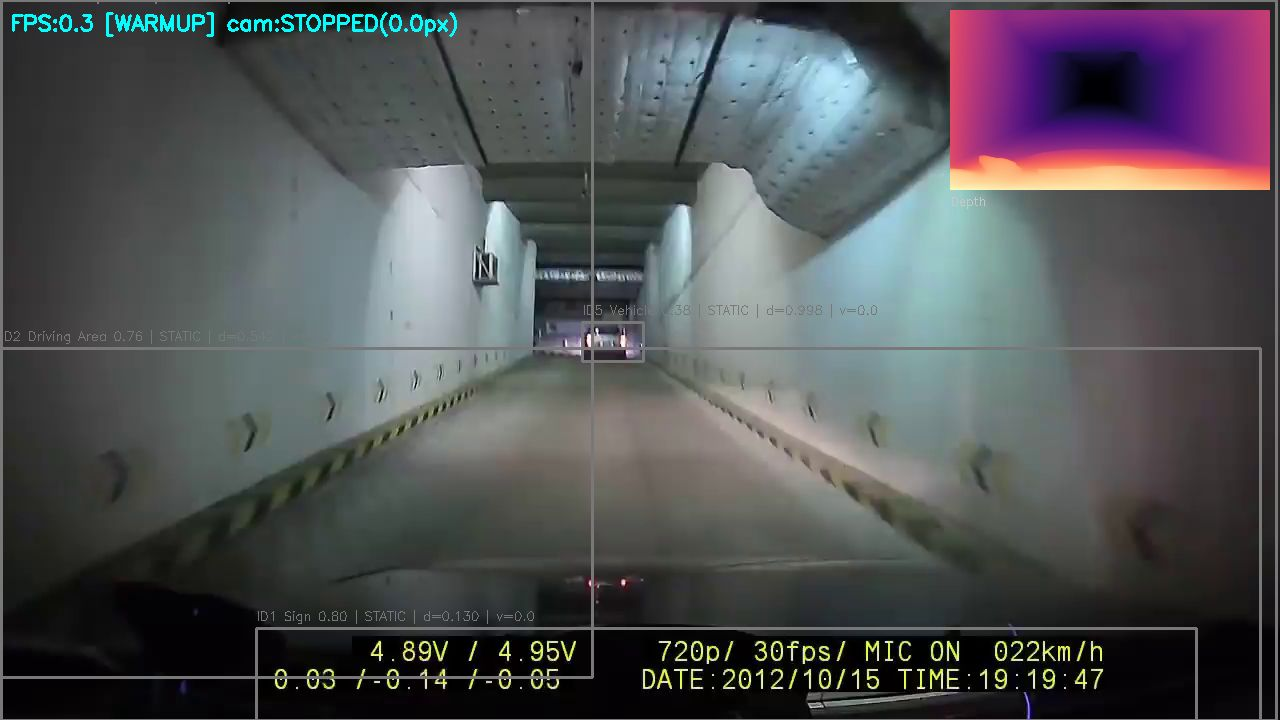

✅ BE OK frame=0 status=200
{
  "frame_id": 5,
  "fps": 16.86,
  "objects_count": 4,
  "ego_motion": {
    "vx": -1.32,
    "vy": 0.56,
    "speed": 1.43
  }
}
{
  "frame_id": 10,
  "fps": 13.56,
  "objects_count": 6,
  "ego_motion": {
    "vx": 0.31,
    "vy": 0.08,
    "speed": 0.32
  }
}
{
  "frame_id": 15,
  "fps": 15.15,
  "objects_count": 5,
  "ego_motion": {
    "vx": -0.12,
    "vy": 1.04,
    "speed": 1.05
  }
}
{
  "frame_id": 20,
  "fps": 14.53,
  "objects_count": 8,
  "ego_motion": {
    "vx": 0.98,
    "vy": 0.43,
    "speed": 1.07
  }
}
{
  "frame_id": 25,
  "fps": 14.29,
  "objects_count": 7,
  "ego_motion": {
    "vx": 0.24,
    "vy": 0.3,
    "speed": 0.39
  }
}
[Depth 기준 확정] min=0.022 max=9.407
{
  "frame_id": 30,
  "fps": 14.55,
  "objects_count": 8,
  "ego_motion": {
    "vx": 0.22,
    "vy": -0.47,
    "speed": 0.52
  }
}
✅ BE OK frame=30 status=200
{
  "frame_id": 35,
  "fps": 13.5,
  "objects_count": 9,
  "ego_motion": {
    "vx": -0.07,
    "vy": -0.55,
    "spee

In [3]:
# ── Depth-Anything-V2 자동 준비 ──────────────────────
import os, sys, importlib, importlib.util, subprocess

if not os.path.exists("/content/Depth-Anything-V2"):
    subprocess.run(["git", "clone",
                    "https://github.com/DepthAnything/Depth-Anything-V2"],
                   check=True)
    print("✅ 레포 클론 완료")
else:
    print("✅ 레포 이미 존재")

subprocess.run(["pip", "install", "-q", "-r",
                "/content/Depth-Anything-V2/requirements.txt"], check=True)

init_path = "/content/Depth-Anything-V2/depth_anything_v2/__init__.py"
if not os.path.exists(init_path):
    open(init_path, "w").close()

path = "/content/Depth-Anything-V2"
pkg  = f"{path}/depth_anything_v2"
for key in list(sys.modules.keys()):
    if "depth_anything" in key:
        del sys.modules[key]
sys.path = [p for p in sys.path if p != path]
sys.path.insert(0, path)
pkg_spec = importlib.util.spec_from_file_location(
    "depth_anything_v2", f"{pkg}/__init__.py",
    submodule_search_locations=[pkg])
pkg_mod = importlib.util.module_from_spec(pkg_spec)
sys.modules["depth_anything_v2"] = pkg_mod
pkg_spec.loader.exec_module(pkg_mod)

os.makedirs("/content/checkpoints", exist_ok=True)
ckpt_local = "/content/checkpoints/depth_anything_v2_vits.pth"
ckpt_drive = "/content/drive/MyDrive/Colab Notebooks/IDA/checkpoints/depth_anything_v2_vits.pth"
if not os.path.exists(ckpt_local):
    if os.path.exists(ckpt_drive):
        subprocess.run(["cp", ckpt_drive, ckpt_local], check=True)
        print("✅ Drive에서 체크포인트 복사 완료")
    else:
        subprocess.run([
            "wget", "-q", "-O", ckpt_local,
            "https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth"
        ], check=True)
        os.makedirs(os.path.dirname(ckpt_drive), exist_ok=True)
        subprocess.run(["cp", ckpt_local, ckpt_drive], check=True)
        print("✅ 다운로드 및 Drive 백업 완료")
else:
    print("✅ 체크포인트 이미 존재")
print("✅ Depth-Anything-V2 준비 완료")
# ─────────────────────────────────────────────────────

import cv2, numpy as np, torch, time, sqlite3
import requests, threading, queue, uuid, math
from collections import defaultdict, deque
import json
from collections import defaultdict, deque
from datetime import datetime, timezone
from ultralytics import YOLO
from IPython.display import display, Image as IPImage
from depth_anything_v2.dpt import DepthAnythingV2

# ──────────────────────────────────────────
# 세션 ID 생성
# ──────────────────────────────────────────
SESSION_ID = None

# ──────────────────────────────────────────
# 설정값
# ──────────────────────────────────────────
BE_SERVER_URL   = "https://unfocusedly-pleurocarpous-gina.ngrok-free.dev"
DETECT_ENDPOINT = f"{BE_SERVER_URL}/detect"
BE_SEND_EVERY = 5      # 5프레임마다 1회 전송 (ngrok 부하 감소)
BE_TIMEOUT    = 10     # timeout 2초 → 10초로 늘림
DISPLAY_EVERY = 99999

# BE 연결 확인
try:
    r = requests.get(f"{BE_SERVER_URL}/docs", timeout=3)
    print("✅ BE 연결 성공:", r.status_code)
except Exception as e:
    print("❌ BE 연결 실패:", e)

DEPTH_INTERVAL  = 5
EMA_ALPHA_DEPTH = 0.3
EMA_ALPHA_BBOX  = 0.4
CLEANUP_FRAMES  = 30
WARMUP_FRAMES   = 30

# ── 정적/동적 판단 설정 ──────────────────
OBJ_HISTORY_FRAMES        = 10
RELATIVE_MOTION_THRESHOLD = 8.0   # 보정 후 속도 임계값 (픽셀/프레임)
DEPTH_CHANGE_THRESHOLD    = 0.06  # depth 변화 임계값
AREA_CHANGE_THRESHOLD     = 0.015 # bbox 면적 변화 임계값
# ego-motion 크기 기준 내 차량 정지 판단
# (CAN 없이 배경 객체 이동량으로 추정)
EGO_STOPPED_THRESHOLD     = 1.5   # 이 이하면 카메라(내 차) 정지로 판단

EGO_MOTION_CLASSES = {
    "Wall", "Pillar", "Parking Line", "Parking Area",
    "No Parking Area", "Non Driving Area", "Driving Area",
}

STATIC_CLASSES = {
    "Wall",
    "Pillar",
    "Parking Line",
    "Parking Area",
    "Non Driving Area",
    "Driving Area"
}

DYNAMIC_WEIGHT = {
    "Car": 1.0,
    "Bus": 1.1,
    "Truck": 1.1,
    "Person": 1.3,
    "Bike": 1.2,

    "Traffic Cone": 0.6,
    "Box": 0.5,
    "Object": 0.5
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ──────────────────────────────────────────
# BE 세션 시작 (추론 루프 전 필수 호출)
# ──────────────────────────────────────────
SESSION_START_ENDPOINT = f"{BE_SERVER_URL}/session/start"
SESSION_END_ENDPOINT   = f"{BE_SERVER_URL}/session/end"

def start_be_session(user_id="test_user", vehicle_id="test_vehicle_01",
                     scenario="normal"):
    """
    BE에 세션 시작 요청
    SessionStartRequest: {user_id, vehicle_id, scenario}
    SessionStartResponse: {session_id, start_time, initial_score, status}
    """
    try:
        resp = requests.post(SESSION_START_ENDPOINT, json={
            "user_id":    user_id,
            "vehicle_id": vehicle_id,
            "scenario":   scenario,
        }, timeout=5)

        if resp.status_code in (200, 201):
            data = resp.json()
            print(f"✅ BE 세션 시작 완료")
            print(f"   session_id   : {data.get('session_id')}")
            print(f"   initial_score: {data.get('initial_score')}")
            print(f"   status       : {data.get('status')}")
            return data.get("session_id")
        else:
            print(f"❌ BE 세션 시작 실패 {resp.status_code}: {resp.text}")
            return None
    except Exception as e:
        print(f"❌ BE 세션 시작 오류: {e}")
        return None

def end_be_session():
    """BE에 세션 종료 요청"""
    try:
        resp = requests.post(SESSION_END_ENDPOINT, json={
            "session_id": SESSION_ID
        }, timeout=5)

        if resp.status_code in (200, 201):
            print("✅ BE 세션 종료 완료")
        else:
            print(f"❌ BE 세션 종료 실패: {resp.status_code}: {resp.text}")

    except Exception as e:
        print(f"❌ BE 세션 종료 오류: {e}")

# ──────────────────────────────────────────
# numpy → Python 기본 타입 변환
# ──────────────────────────────────────────
def to_python_type(obj):
    if isinstance(obj, dict):
        return {k: to_python_type(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_type(v) for v in obj]
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# ──────────────────────────────────────────
# BE 비동기 전송
# ──────────────────────────────────────────
send_queue = queue.Queue(maxsize=200)

def be_sender():
    while True:
        try:
            task = send_queue.get(timeout=1)
            if task is None:
                break
            endpoint, payload = task
            try:
                resp = requests.post(endpoint, json=payload,
                                     timeout=BE_TIMEOUT)  # ← 수정
                if payload["frame_id"] % 30 == 0:
                    print(f"✅ BE OK frame={payload['frame_id']} "
                          f"status={resp.status_code}")
                if resp.status_code not in (200, 201):
                    print(f"[BE 응답 오류] {resp.status_code}: "
                          f"{resp.text[:100]}")
            except requests.exceptions.ConnectionError:
                pass
            except requests.exceptions.Timeout:
                pass  # 타임아웃도 조용히 스킵
            except Exception as e:
                print(f"[BE 전송 실패] {e}")
        except queue.Empty:
            continue

sender_thread = threading.Thread(target=be_sender, daemon=True)
sender_thread.start()

def post_to_be(endpoint, payload):
    try:
        send_queue.put_nowait((endpoint, to_python_type(payload)))
    except queue.Full:
        pass

# ──────────────────────────────────────────
# 모델 로드
# ──────────────────────────────────────────
yolo_model = YOLO(
    "/content/drive/MyDrive/Colab Notebooks/IDA/IDA_runs/"
    "yolov8s_ida_v1/weights/best.pt")

cfg = {"features": 64, "out_channels": [48, 96, 192, 384]}
depth_model = DepthAnythingV2(encoder="vits", **cfg)
depth_model.load_state_dict(
    torch.load("./checkpoints/depth_anything_v2_vits.pth",
               map_location="cpu"))
depth_model = depth_model.to(DEVICE).eval()
print(f"[모델 로드 완료] YOLO + Depth Anything v2 ({DEVICE})")

# ──────────────────────────────────────────
# CLAHE (AC002)
# ──────────────────────────────────────────
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe_if_dark(frame, brightness_threshold=80):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    if gray.mean() < brightness_threshold:
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = clahe.apply(l)
        return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)
    return frame

# ──────────────────────────────────────────
# EMA (MR003, MR004)
# ──────────────────────────────────────────
ema_depth_cache = {}
ema_bbox_cache  = {}
ego_motion_cache = {
    "vx": 0.0,
    "vy": 0.0
}

EGO_EMA_ALPHA = 0.2
depth_history = defaultdict(lambda: deque(maxlen=5))
DEPTH_ALPHA = 0.3

def ema_update_depth(track_id, new_val):
    if track_id not in ema_depth_cache:
        ema_depth_cache[track_id] = new_val
    else:
        ema_depth_cache[track_id] = (
            EMA_ALPHA_DEPTH * new_val
            + (1 - EMA_ALPHA_DEPTH) * ema_depth_cache[track_id])
    return ema_depth_cache[track_id]

def ema_update_bbox(track_id, new_box):
    if track_id not in ema_bbox_cache:
        ema_bbox_cache[track_id] = new_box
    else:
        ema_bbox_cache[track_id] = [
            EMA_ALPHA_BBOX * n + (1 - EMA_ALPHA_BBOX) * o
            for n, o in zip(new_box, ema_bbox_cache[track_id])]
    return ema_bbox_cache[track_id]

def smooth_depth(track_id, raw_depth):
    """
    1) median filter + 2) EMA smoothing
    """
    # 1. history 저장
    depth_history[track_id].append(raw_depth)

    # 2. median filter (noise 제거)
    median_depth = float(np.median(depth_history[track_id]))

    # 3. EMA smoothing
    if track_id not in ema_depth_cache:
        ema_depth_cache[track_id] = median_depth
    else:
        ema_depth_cache[track_id] = (
            DEPTH_ALPHA * median_depth +
            (1 - DEPTH_ALPHA) * ema_depth_cache[track_id]
        )

    return ema_depth_cache[track_id]

# ──────────────────────────────────────────
# 정적/동적 판단 (CAN 없이 ego-motion 기반)
# ──────────────────────────────────────────
obj_center_history = defaultdict(lambda: deque(maxlen=OBJ_HISTORY_FRAMES))
depth_history      = defaultdict(lambda: deque(maxlen=5))
area_history       = defaultdict(lambda: deque(maxlen=5))

def estimate_ego_motion(raw_motion_list):
    """
    전체 객체 이동의 중앙값으로 카메라(내 차) 이동량 추정
    배경 객체가 많을수록 정확도 향상
    """
    if len(raw_motion_list) < 2:
        return 0.0, 0.0
    all_vx = [v[2] for v in raw_motion_list]
    all_vy = [v[3] for v in raw_motion_list]
    return float(np.median(all_vx)), float(np.median(all_vy))

def smooth_ego_motion(vx, vy):
    ego_motion_cache["vx"] = (
        EGO_EMA_ALPHA * vx +
        (1 - EGO_EMA_ALPHA) * ego_motion_cache["vx"]
    )

    ego_motion_cache["vy"] = (
        EGO_EMA_ALPHA * vy +
        (1 - EGO_EMA_ALPHA) * ego_motion_cache["vy"]
    )

    return ego_motion_cache["vx"], ego_motion_cache["vy"]

def get_object_motion(tid, cx, cy, depth_val, bbox_area_ratio,
                      ego_vx, ego_vy, ego_speed, cls_name):
    """
    CAN 없이 ego-motion 크기로 내 차 정지 여부 판단
    ego_speed: ego-motion 벡터 크기 (픽셀/프레임)
    """
    center_hist = obj_center_history[tid]
    center_hist.append((cx, cy))
    d_hist = depth_history[tid]
    a_hist = area_history[tid]
    if depth_val is not None:
        d_hist.append(depth_val)
    a_hist.append(bbox_area_ratio)

    if len(center_hist) < 3:
        return 0.0, 0.0, 0.0, False

    # 최근 3프레임 평균 속도 (노이즈 감소)
    recent  = list(center_hist)[-3:]
    raw_vx  = (recent[-1][0] - recent[0][0]) / 2.0
    raw_vy  = (recent[-1][1] - recent[0][1]) / 2.0

    # ego-motion 보정
    corr_vx  = raw_vx - ego_vx
    corr_vy  = raw_vy - ego_vy
    speed_px = math.sqrt(corr_vx**2 + corr_vy**2)

    depth_change = abs(d_hist[-1] - d_hist[0]) if len(d_hist) >= 3 else 0.0
    area_change  = abs(a_hist[-1] - a_hist[0]) if len(a_hist) >= 3 else 0.0

    # 내 차 정지 판단 — CAN 대신 ego-motion 크기 사용
    ego_is_stopped = ego_speed < EGO_STOPPED_THRESHOLD

    # 내 차 정지 판단
    ego_is_stopped = ego_speed < EGO_STOPPED_THRESHOLD

    # -----------------------------
    # STATIC CLASS는 항상 정지 처리
    # -----------------------------
    if cls_name in STATIC_CLASSES:
        return corr_vx, corr_vy, 0.0, False

    # -----------------------------
    # ego stopped
    # -----------------------------
    if ego_is_stopped:

        # 내 차 정지 상태에서는
        # 작은 움직임도 민감하게 감지
        is_moving = speed_px > 1.5

    # -----------------------------
    # ego moving
    # -----------------------------
    else:

        class_weight = DYNAMIC_WEIGHT.get(cls_name, 0.7)

        # 가까운 객체일수록 motion 민감도 증가
        depth_factor = 1.0

        if depth_val is not None:
            depth_factor = 1.0 + (depth_val * 2.0)

        motion_score = speed_px * class_weight

        is_moving = (
          motion_score > RELATIVE_MOTION_THRESHOLD
          and (
              depth_change > DEPTH_CHANGE_THRESHOLD
              or area_change > AREA_CHANGE_THRESHOLD
          )
      )

    # -----------------------------
    # 작은 노이즈 제거
    # -----------------------------
    if speed_px < 2.0:
        is_moving = False

    return corr_vx, corr_vy, speed_px, is_moving

# ──────────────────────────────────────────
# bbox 픽셀 → 정규화 (BE BBox 스키마)
# ──────────────────────────────────────────
def to_normalized_bbox(sx1, sy1, sx2, sy2, frame_w, frame_h):
    """BE BBox 스키마: {x, y, w, h} 정규화 0~1, 좌상단 기준"""
    x = max(0.0, float(sx1) / frame_w)
    y = max(0.0, float(sy1) / frame_h)
    w = min(1.0, float(sx2 - sx1) / frame_w)
    h = min(1.0, float(sy2 - sy1) / frame_h)
    return {"x": round(x, 4), "y": round(y, 4),
            "w": round(w, 4), "h": round(h, 4)}

# ──────────────────────────────────────────
# 캐시 정리
# ──────────────────────────────────────────
last_seen = {}

def cleanup_cache(frame_id):
    stale_ids = [tid for tid, last in last_seen.items()
                 if frame_id - last > CLEANUP_FRAMES]
    for tid in stale_ids:
        ema_depth_cache.pop(tid, None)
        ema_bbox_cache.pop(tid, None)
        obj_center_history.pop(tid, None)
        depth_history.pop(tid, None)
        area_history.pop(tid, None)
        last_seen.pop(tid, None)

# ──────────────────────────────────────────
# depth 시각화
# ──────────────────────────────────────────
def make_depth_overlay(depth_map, size):
    if depth_map is None:
        return np.zeros((size[1], size[0], 3), dtype=np.uint8)
    d_vis   = (depth_map * 255).astype(np.uint8)
    d_color = cv2.applyColorMap(d_vis, cv2.COLORMAP_MAGMA)
    return cv2.resize(d_color, size)

# ──────────────────────────────────────────
# Colab 인라인 출력
# ──────────────────────────────────────────
def show_frame_inline(frame):
    _, buf = cv2.imencode('.jpg', frame, [cv2.IMWRITE_JPEG_QUALITY, 80])
    display(IPImage(data=buf.tobytes()))

# ──────────────────────────────────────────
# 메인 추론 루프
# ──────────────────────────────────────────
# BE 세션 시작 — 추론 루프 전 필수
SESSION_ID = start_be_session(
    user_id="test_user",
    vehicle_id="test_vehicle_01",
    scenario="normal"
)

if SESSION_ID is None:
    raise Exception("BE session 생성 실패")

cap = cv2.VideoCapture(
    "/content/drive/MyDrive/Colab Notebooks/IDA/test3.mp4")
frame_h    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_w    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_area = frame_h * frame_w

frame_id   = 0
depth_map  = None
known_ids  = set()
fps_buffer = []
t_prev     = time.time()

depth_stats      = []
depth_global_min = None
depth_global_max = None

while cap.isOpened():
    t_start = time.time()
    ret, frame = cap.read()
    if not ret:
        break

    frame_input = apply_clahe_if_dark(frame)
    results = yolo_model.track(frame_input, persist=True,
                               imgsz=640, verbose=False)

    t_now = time.time()
    fps_buffer.append(1.0 / max(t_now - t_prev, 1e-6))
    t_prev = t_now
    if len(fps_buffer) > 30:
        fps_buffer.pop(0)

    current_ids = set()
    if results[0].boxes is not None and results[0].boxes.id is not None:
        current_ids = set(results[0].boxes.id.int().tolist())
    new_ids   = current_ids - known_ids
    known_ids = current_ids

    run_depth = (frame_id % DEPTH_INTERVAL == 0) or (len(new_ids) > 0)
    if run_depth:
        try:
            img_rgb = cv2.cvtColor(frame_input, cv2.COLOR_BGR2RGB)

            # Depth 전용 축소 입력
            depth_input = cv2.resize(img_rgb, (320, 180))

            with torch.no_grad():
                depth_small = depth_model.infer_image(depth_input)

            # 다시 원본 크기로 복원
            depth_raw = cv2.resize(
                depth_small,
                (frame_w, frame_h)
            )

            if frame_id < WARMUP_FRAMES:
                depth_stats.append((float(depth_raw.min()),
                                     float(depth_raw.max())))
                d_min, d_max = depth_raw.min(), depth_raw.max()
                depth_map = (depth_raw - d_min) / (d_max - d_min + 1e-8)
            elif frame_id == WARMUP_FRAMES:
                depth_global_min = float(
                    np.percentile([s[0] for s in depth_stats], 10))
                depth_global_max = float(
                    np.percentile([s[1] for s in depth_stats], 90))
                print(f"[Depth 기준 확정] "
                      f"min={depth_global_min:.3f} "
                      f"max={depth_global_max:.3f}")
                depth_map = np.clip(
                    (depth_raw - depth_global_min)
                    / (depth_global_max - depth_global_min + 1e-8), 0, 1)
            else:
                depth_map = np.clip(
                    (depth_raw - depth_global_min)
                    / (depth_global_max - depth_global_min + 1e-8), 0, 1)
        except Exception as e:
            print(f"[Depth 오류] {e}")

    frame_out        = frame.copy()
    frame_detections = []

    # ── 1패스: ego-motion 추정 ──────────────────────
    raw_motion_list = []
    if results[0].boxes is not None and results[0].boxes.id is not None:
        for box, tid, cls_id in zip(
            results[0].boxes.xyxy.cpu().numpy(),
            results[0].boxes.id.int().cpu().tolist(),
            results[0].boxes.cls.int().cpu().tolist()
        ):
            x1, y1, x2, y2 = box
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)
            hist = obj_center_history[tid]
            vx, vy = ((float(cx - hist[-1][0]), float(cy - hist[-1][1]))
                      if len(hist) >= 1 else (0.0, 0.0))
            raw_motion_list.append(
                (tid, results[0].names[cls_id], vx, vy))

    ego_vx, ego_vy = estimate_ego_motion(raw_motion_list)

    # 🔥 추가
    ego_vx, ego_vy = smooth_ego_motion(ego_vx, ego_vy)

    ego_speed = math.sqrt(ego_vx**2 + ego_vy**2)

    # ── 2패스: 객체별 처리 ──────────────────────────
    if results[0].boxes is not None and results[0].boxes.id is not None:
        boxes     = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.int().cpu().tolist()
        confs     = results[0].boxes.conf.cpu().numpy()
        cls_ids   = results[0].boxes.cls.int().cpu().tolist()
        cls_names = results[0].names

        for box, tid, conf, cls_id in zip(boxes, track_ids, confs, cls_ids):
            x1, y1, x2, y2 = box
            cls_name = cls_names[cls_id]

            sx1, sy1, sx2, sy2 = ema_update_bbox(tid, [x1, y1, x2, y2])
            last_seen[tid] = frame_id

            cx = np.clip(int((sx1+sx2)/2), 0,
                         depth_map.shape[1]-1 if depth_map is not None else 0)
            cy = np.clip(int((sy1+sy2)/2), 0,
                         depth_map.shape[0]-1 if depth_map is not None else 0)

            depth_val = None
            if depth_map is not None:

                # bbox 범위 안전하게 자르기
                ix1 = max(0, int(sx1))
                iy1 = max(0, int(sy1))
                ix2 = min(depth_map.shape[1] - 1, int(sx2))
                iy2 = min(depth_map.shape[0] - 1, int(sy2))

                # bbox 내부 depth 추출
                roi_depth = depth_map[iy1:iy2, ix1:ix2]

                # bbox 내부 median depth 사용
                if roi_depth.size > 0:
                    raw_depth = float(np.median(roi_depth))
                else:
                    raw_depth = 0.5

                # depth smoothing
                smoothed = smooth_depth(tid, raw_depth)

                # 가까울수록 큰 값 (위험도)
                depth_val = 1.0 - smoothed

            else:
                depth_val = None

            bbox_area_ratio = float((sx2 - sx1) * (sy2 - sy1)) / frame_area

            # 정적/동적 판단 (CAN 없이 ego_speed 사용)
            corr_vx, corr_vy, speed_px, is_moving = get_object_motion(tid, cx, cy, depth_val, bbox_area_ratio,
                  ego_vx, ego_vy, ego_speed, cls_name)

            # 시각화
            box_color  = (0, 0, 255)    if is_moving else (120, 120, 120)
            move_label = "MOVING"       if is_moving else "STATIC"
            depth_str  = f"d={depth_val:.3f}" if depth_val else "d=N/A"
            label = (f"ID{tid} {cls_name} {conf:.2f} "
                     f"| {move_label} | {depth_str} | v={speed_px:.1f}")

            cv2.rectangle(frame_out,
                          (int(sx1), int(sy1)), (int(sx2), int(sy2)),
                          box_color, 2)
            cv2.putText(frame_out, label,
                        (int(sx1), max(int(sy1)-8, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, box_color, 1)

            if is_moving and speed_px > 2.0:
                arrow_end = (int(cx + corr_vx*3), int(cy + corr_vy*3))
                cv2.arrowedLine(frame_out, (cx, cy), arrow_end,
                                (255, 100, 0), 2, tipLength=0.3)

            # BE DetectedObject 스키마
            norm_bbox = to_normalized_bbox(sx1, sy1, sx2, sy2,
                                           frame_w, frame_h)
            safe_depth = None

            if depth_val is not None:
                if np.isfinite(depth_val):
                    safe_depth = round(float(depth_val), 4)

            det = {
                "class_id": cls_id,
                "class_name": cls_name,
                "confidence": round(float(conf), 4),
                "bbox": norm_bbox,

                "track_id": int(tid),

                "depth_val": safe_depth,

                "bbox_area_ratio": round(float(bbox_area_ratio), 4),
                "bbox_velocity_x": round(float(corr_vx), 2),
                "bbox_velocity_y": round(float(corr_vy), 2),
                "obj_speed_px": round(float(speed_px), 2),
                "is_moving": bool(is_moving),
            }
            frame_detections.append(det)

    # ── BE POST (DetectionResult 스키마) ────────────
    t_end = time.time()
    inference_time_ms = (t_end - t_start) * 1000
    avg_fps = sum(fps_buffer) / len(fps_buffer) if fps_buffer else 0
    #수정

    if frame_id % BE_SEND_EVERY == 0:
        print(json.dumps({
          "frame_id": frame_id,
          "fps": round(avg_fps, 2),
          "objects_count": len(frame_detections),
          "ego_motion": {
              "vx": round(float(ego_vx), 2),
              "vy": round(float(ego_vy), 2),
              "speed": round(float(ego_speed), 2),
          }
      }, indent=2))
        post_to_be(DETECT_ENDPOINT, {
            "frame_id":          frame_id,
            "timestamp":         datetime.now(timezone.utc).isoformat(),
            "fps":               round(avg_fps, 2),
            "inference_time_ms": round(inference_time_ms, 1),
            "session_id":        SESSION_ID,
            "objects":           frame_detections,
            "ego_motion": {
                "vx":    round(float(ego_vx), 2),
                "vy":    round(float(ego_vy), 2),
                "speed": round(float(ego_speed), 2),
            },
        })
    '''
    payload = {
        "frame_id": frame_id,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "fps": round(avg_fps, 2),
        "inference_time_ms": round(inference_time_ms, 1),
        "session_id": SESSION_ID,
        "objects": frame_detections,
        "ego_motion": {
            "vx": round(float(ego_vx), 2),
            "vy": round(float(ego_vy), 2),
            "speed": round(float(ego_speed), 2),
        },
    }

    print("📡 BE SEND JSON:")
    if frame_id % 30 == 0:
        print(f"[BE SEND] frame={frame_id}, objs={len(frame_detections)}")

    post_to_be(DETECT_ENDPOINT, payload)
    '''
    #수정

    # 화면 오버레이
    status = "WARMUP" if frame_id < WARMUP_FRAMES else "ACTIVE"
    ego_stopped = "STOPPED" if ego_speed < EGO_STOPPED_THRESHOLD else "MOVING"
    cv2.putText(frame_out,
                f"FPS:{avg_fps:.1f} [{status}] "
                f"cam:{ego_stopped}({ego_speed:.1f}px)",
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

    if depth_map is not None and frame_id % DISPLAY_EVERY == 0:
        dw   = frame_out.shape[1] // 4
        dh   = frame_out.shape[0] // 4
        dvis = make_depth_overlay(depth_map, (dw, dh))
        frame_out[10:10+dh,
                  frame_out.shape[1]-dw-10:frame_out.shape[1]-10] = dvis
        cv2.putText(frame_out, "Depth",
                    (frame_out.shape[1]-dw-10, 10+dh+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)

    if frame_id % DISPLAY_EVERY == 0:
        show_frame_inline(frame_out)

    cleanup_cache(frame_id)
    frame_id += 1

send_queue.put(None)

# BE 세션 종료
end_be_session()

print(f"\n✅ 완료: 총 {frame_id}프레임 처리")
print(f"🔑 세션 ID: {SESSION_ID}")